# Python Types and the Package Ecosystem

> Computational Analysis of Social Complexity
>
> Fall 2025, Spencer Lyon

**Prerequisites**

- Laptop or personal computer with internet connection
- Python Foundations lecture

**Outcomes**

- Understand key components of Python's type system: the object model, abstract base classes, and classes/dataclasses
- Be able to define our own custom types (classes) to hold data
- Understand how Python resolves which code runs for a given type
- Organize code into `.py` files and packages, and import code across files
- Install, uninstall, and update packages with `uv`, and understand `pyproject.toml`/`uv.lock`
- Create a new Python package to organize code snippets

**References**

- Lecture notes
- Python documentation on the [data model](https://docs.python.org/3/reference/datamodel.html), [dataclasses](https://docs.python.org/3/library/dataclasses.html), and [modules](https://docs.python.org/3/tutorial/modules.html)
- [`functools.singledispatch`](https://docs.python.org/3/library/functools.html#functools.singledispatch) documentation
- [`uv` documentation](https://docs.astral.sh/uv/)

## Part 1: Types in Python

- Python is a dynamically typed, interpreted language
- Its type system organizes data into types, and lets you write code that behaves differently depending on the type of its input
- Understanding Python's type model will make you a much more effective Python programmer

### What is a type?

- Each piece of data in a program resides in memory (RAM) on the host computer
- We often assign names to data, which we call variables (in `x = "hello"`, `x` is a variable)
- In Python, *everything* is an object: an arrangement of bits in memory, tagged with a `type` that tells the interpreter what operations are valid on it and where to find its data
- A **type** in Python is itself an object (an instance of `class`), and `type(x)` tells you the type of any variable `x`
- Python uses this type information at *runtime* to decide what behaviors are defined to operate on the data

### Organizing types

- In Python, types (classes) are organized into a hierarchy
- At the top of the hierarchy is `object` -- every class in Python is a subclass of `object`
- A class *can* have more than one parent (Python supports multiple inheritance)
- Types can come in a few different flavors...

### Types of Types

- Built-in types: provided to us by Python and represent fundamental kinds of data (e.g. `int`, `float`, `bool`, `str`)
- Abstract base classes (ABCs): cannot be instantiated directly, but serve as nodes in a type hierarchy. Help us organize types into families and provide shared behavior for all members of the family
- Regular classes / dataclasses: types that contain additional data called attributes (or fields). An instance can be treated as a single value. This is what we typically define and use

> NOTE: all objects in Python are instances of some class, and can be related to one another by sharing common abstract base class ancestors

## Abstract Base Classes

- Abstract base classes help organize concrete classes into families
- Python's standard library `numbers` module gives us a hierarchy for the built-in number types (see the [`numbers` module documentation](https://docs.python.org/3/library/numbers.html))
```python
numbers.Number
numbers.Complex
numbers.Real
numbers.Rational
numbers.Integral
```
- Note:
  - `numbers.Number`'s parent is `object`
  - `numbers.Real` is a special kind of `numbers.Complex`, and `numbers.Integral` is a special kind of `numbers.Rational`


### Why Abstract Base Classes?

- We said before we can't create an instance of an abstract base class...
- So, why do we have them?
- The primary reason to have them is to introduce shared functionality via `isinstance` checks written against the abstract class, rather than a long list of concrete types



- Example: suppose you needed to define a function `isint` to determine if an object is an integer
  - Without abstract base classes, you could have a long sequence of checks for every concrete integer type:


In [1]:

import numpy as np


def isint1(x):
    for T in (
        int, np.int8, np.uint8, np.int16, np.uint16,
        np.int32, np.uint32, np.int64, np.uint64,
    ):
        if isinstance(x, T):
            return True
    return False


isint1(10), isint1("Hello")


(True, False)

With abstract base classes we can write a single check:


In [2]:

import numbers


def isint(x):
    return isinstance(x, numbers.Integral)


isint(10), isint("Hello")


(True, False)


- This has many benefits
  - Much simpler to write/reason about
  - More "fool proof": what if we forgot one of the `np.uintXX` types?
  - More "future proof": if a brand new integer type gets introduced by some other library, as long as it registers with `numbers.Integral` (`numpy`'s integer types already do this), our `isint` keeps working with zero changes
  - Pushes work out of our function body and into a single, well-tested `isinstance` call


In [3]:
import dis

dis.dis(isint1)  # a handful of type checks, one per concrete type


  4           0 RESUME                   0

  6           2 LOAD_GLOBAL              0 (int)
             12 LOAD_GLOBAL              2 (np)
             22 LOAD_ATTR                4 (int8)
             42 LOAD_GLOBAL              2 (np)
             52 LOAD_ATTR                6 (uint8)
             72 LOAD_GLOBAL              2 (np)
             82 LOAD_ATTR                8 (int16)
            102 LOAD_GLOBAL              2 (np)
            112 LOAD_ATTR               10 (uint16)

  7         132 LOAD_GLOBAL              2 (np)
            142 LOAD_ATTR               12 (int32)
            162 LOAD_GLOBAL              2 (np)
            172 LOAD_ATTR               14 (uint32)
            192 LOAD_GLOBAL              2 (np)
            202 LOAD_ATTR               16 (int64)
            222 LOAD_GLOBAL              2 (np)
            232 LOAD_ATTR               18 (uint64)

  5         252 BUILD_TUPLE              9
            254 GET_ITER
        >>  256 FOR_ITER                16 

In [4]:
dis.dis(isint)  # a single isinstance check against the abstract base class


  4           0 RESUME                   0

  5           2 LOAD_GLOBAL              1 (NULL + isinstance)
             12 LOAD_FAST                0 (x)
             14 LOAD_GLOBAL              2 (numbers)
             24 LOAD_ATTR                4 (Integral)
             44 CALL                     2
             52 RETURN_VALUE


## Classes and Dataclasses

- Abstract base classes are very useful when combined with `isinstance`-based branching
- However, most often we create types to hold collections of related data together
- We do this using classes -- and, most conveniently, the `@dataclass` decorator from the standard library `dataclasses` module
- A dataclass can be created as follows:
```python
from dataclasses import dataclass


@dataclass
class Name:
    field1: Field1Type
    # more fields
```
- `@dataclass` automatically writes the boilerplate `__init__`, `__repr__`, and `__eq__` methods for you, based on the type-annotated attributes you list

### Classes: Examples


In [5]:

from dataclasses import dataclass, fields


@dataclass
class Foo:
    bar: object
    baz: int
    qux: float


In [6]:
foo = Foo("Hello, world.", 23, 1.5)


In [7]:
type(foo)


__main__.Foo

- Note that a plain `@dataclass` does **not** enforce the field types at runtime -- the annotations are hints, not guarantees
- If you want real runtime validation, reach for `pydantic`'s `BaseModel` instead of `@dataclass`; we'll use `pydantic` later in the course when that guarantee matters

In [8]:
[f.name for f in fields(Foo)]


['bar', 'baz', 'qux']

In [9]:
foo.bar


'Hello, world.'

In [10]:
foo.baz


23

In [11]:
foo.qux


1.5

### Classes and Dispatch

- Above we saw an example of writing multiple `isinstance` branches, using an abstract base class to organize the checks
- Sometimes we want to define several versions of a function, each specialized to a different argument type, and have the language pick the right one automatically -- this is called *dispatch*
- Python does not have true multiple dispatch (dispatch on the types of every argument at once). The closest built in tool is `functools.singledispatch`, which lets you register specialized implementations of a function by the type of its **first** argument only

In [12]:

from functools import singledispatch


@singledispatch
def isint(x):
    return False


@isint.register
def _(x: numbers.Integral):
    return True


@isint.register
def _(x: Foo):
    return isint(x.bar)


In [13]:
isint(10), isint(1.0), isint(np.uint64(234901324987213)), isint(Foo("not an int", 12, 1.0))


(True, False, True, False)

In [14]:
foo, isint(foo)


(Foo(bar='Hello, world.', baz=23, qux=1.5), False)

In [15]:
isint(Foo(1, 23, 1.5))


True

### Exercises

1. Create an abstract base class called `Person` (subclass `abc.ABC`)
2. Create two dataclasses `Friend` and `Foe`, both subclasses of `Person`
   - Each of these should have fields `name: str` and `height_inches: float`
   - `Friend` should also have a field `favorite_color: str`
   - MAKE SURE TO ADD TYPE ANNOTATIONS FOR ALL FIELDS
3. Create a third dataclass subtype of `Person` called `Stranger`, but without any fields
4. Suppose we are trying to decide who to invite to a dinner party. Our rule is that friends should get a definite yes. Foes a definite no. Strangers a 50%/50% toss up. However, if our spouse says we should invite a person, the answer is always yes
   - Create a function `should_invite_to_party(person, spouse_says_yes=False)` that implements that logic
   - HINT: since `functools.singledispatch` only dispatches on the *first* argument, the cleanest Python solution uses `isinstance` checks inside one function body, combined with the `spouse_says_yes` keyword argument
5. In the cell at the bottom we have written a test case. You will know you've done this correctly when all the tests pass

In [16]:
# Your code here


In [17]:



def tests():
    assert [f.name for f in fields(Friend)] == ["name", "height_inches", "favorite_color"]
    assert [f.name for f in fields(Foe)] == ["name", "height_inches"]
    assert [f.name for f in fields(Stranger)] == []


    jim = Friend("Jim", 64, "blue")
    dwight = Foe("Dwight", 61)
    creed = Stranger()


    assert isinstance(jim, Person)
    assert isinstance(dwight, Person)
    assert isinstance(creed, Person)


    assert should_invite_to_party(jim)
    assert not should_invite_to_party(dwight)
    assert should_invite_to_party(dwight, spouse_says_yes=True)


    creed_invites = [should_invite_to_party(creed) for _ in range(100)]
    assert any(creed_invites)
    assert any(not invite for invite in creed_invites)


    creed_invites_spouse = [should_invite_to_party(creed, spouse_says_yes=True) for _ in range(100)]
    assert all(creed_invites_spouse)


    print("all tests passed!")


In [18]:
# uncomment and run this cell when you are ready to test your code
# tests()



## Part 2: Code Organization

* Python can be successfully used for exploratory analysis and one-off scripts
* As projects grow, it is often useful to add structure and organization to the code
* In Python, the main building blocks for code organization and re-use include
    * Classes/dataclasses
    * Functions/methods
    * `.py` source code files (modules)
    * Packages (directories of modules)
* In this notebook we'll learn how to manage `.py` files and packages



## `.py` files

* Python source code lives in a plain text file with a `.py` extension (this one *is* enforced -- the interpreter and import system rely on it)
* Suppose we have the following code for simulating Markov Chains in Python


In [19]:

# Markov Chain code
import numpy as np


class MarkovChain:
    def __init__(self, P, initial_state, state_values):
        self.P = np.asarray(P, dtype=float)
        self.initial_state = np.asarray(initial_state, dtype=float)
        self.state_values = list(state_values)
        self.P_dists = np.cumsum(self.P, axis=1)


def simulate_indices(mc, n_steps):
    init_dist = np.cumsum(mc.initial_state)
    states = np.empty(n_steps, dtype=int)
    states[0] = np.searchsorted(init_dist, np.random.rand())
    for i in range(1, n_steps):
        states[i] = np.searchsorted(mc.P_dists[states[i - 1]], np.random.rand())
    return states


def simulate_values(mc, n_steps):
    states = simulate_indices(mc, n_steps)
    return [mc.state_values[i] for i in states]


In [20]:

np.random.seed(6318)


P1 = np.array([[0.5, 0.5], [0.5, 0.5]])
mc1 = MarkovChain(P1, [1.0, 0.0], ["A", "B"])


type(mc1)


__main__.MarkovChain

In [21]:
mc1.P_dists


array([[0.5, 1. ],
       [0.5, 1. ]])

In [22]:
inds = simulate_indices(mc1, 10)
inds


array([0, 1, 0, 0, 0, 0, 0, 1, 0, 1])

In [23]:
vals = simulate_values(mc1, 10)
vals


['A', 'B', 'A', 'A', 'A', 'B', 'B', 'B', 'A', 'B']


* As you can see, we can use this code from inside a Jupyter notebook by running the defining cell and then calling the routines
* However, what if we wanted to reuse the code for another notebook
* We have two options:
    1. Copy/paste it to the new notebook
    2. Store the code in a `.py` file and import it from both places
* Let's pick the latter



## `import`

* Let's create `markov.py` with that code (plus a couple of extra functions):


In [24]:

%%writefile markov.py
# Markov Chain code
import numpy as np


class MarkovChain:
    def __init__(self, P, initial_state, state_values):
        self.P = np.asarray(P, dtype=float)
        self.initial_state = np.asarray(initial_state, dtype=float)
        self.state_values = list(state_values)
        self.P_dists = np.cumsum(self.P, axis=1)


def simulate_indices(mc, n_steps):
    init_dist = np.cumsum(mc.initial_state)
    states = np.empty(n_steps, dtype=int)
    states[0] = np.searchsorted(init_dist, np.random.rand())
    for i in range(1, n_steps):
        states[i] = np.searchsorted(mc.P_dists[states[i - 1]], np.random.rand())
    return states


def simulate_values(mc, n_steps):
    states = simulate_indices(mc, n_steps)
    return [mc.state_values[i] for i in states]


def rand(mc, n_steps):
    # Draw `n_steps` values from the chain
    return simulate_values(mc, n_steps)


def stationary_distributions(mc):
    eigvals, eigvecs = np.linalg.eig(mc.P.T)
    out = []
    for i in range(mc.P.shape[0]):
        if np.isclose(eigvals[i], 1):
            vec = eigvecs[:, i].real
            vec = vec / vec.sum()
            out.append(vec)
    return out


Writing markov.py


* To make use of this code elsewhere, we `import markov`
* You can think of `import` as running the file *once*, then handing you back a `module` object that holds every name defined at its top level
* A Python `import` **always** creates its own namespace -- every `.py` file is automatically a "module" the moment you import it, with no extra syntax required
* Notice that in `markov.py` I added two extra functions (`rand` and `stationary_distributions`) beyond what we defined inline above

In [25]:
import markov


In [26]:
mc2 = markov.MarkovChain(P1, [1.0, 0.0], ["A", "B"])
markov.rand(mc2, 4)


['A', 'A', 'B', 'B']

In [27]:
markov.stationary_distributions(mc2)


[array([0.5, 0.5])]

* Notice that I had to use `markov.` to access members of the module
* If instead I want to use names directly, without the `markov.` prefix, I can use `from markov import name1, name2`

In [28]:
from markov import MarkovChain, rand, stationary_distributions

mc3 = MarkovChain(P1, [1.0, 0.0], ["A", "B"])
rand(mc3, 4)


['A', 'A', 'B', 'A']

## Packages

* Being able to define code in a `.py` file and `import` it in a notebook (or another `.py` file!) is already a huge win for organization and reusability
* When a project grows past a single file, Python lets us group multiple modules into a **package**: a directory containing an `__init__.py` file
* `__init__.py` controls what a user sees when they do `from my_package import ...`
* A minimal package layout looks like:
```text
geometric_shapes/
    __init__.py
    shapes.py
```
with `__init__.py` containing something like
```python
from .shapes import Shape2D, Circle, Rectangle, Triangle, area, perimeter, is_inside
```
* This is a *very* common pattern in Python projects and is one we will see throughout our course


### Exercise

* Now it is your turn
* Let's create a package for working with geometric shapes
* Create a new directory called `geometric_shapes/` containing:
    1. `shapes.py`: here define the following:
        * An abstract base class `Shape2D` (subclass `abc.ABC`)
        * Concrete dataclasses `Circle`, `Rectangle`, and `Triangle` that are subclasses of `Shape2D`
        * Methods (or functions) for `area` and `perimeter` for each shape type
        * A function `is_inside(shape, x, y)` that checks if a point `(x, y)` is inside the shape
    2. `__init__.py`: here re-export the names from `shapes.py`
        * Export the types: `Shape2D`, `Circle`, `Rectangle`, `Triangle`
        * Export the functions: `area`, `perimeter`, `is_inside`
* `import geometric_shapes` (or `from geometric_shapes import ...`) and test it by:
  * Creating instances of each shape
  * Computing their areas and perimeters
  * Testing if various points are inside or outside the shapes



## Part 3: The Package Ecosystem

* Python is a very powerful, modern language
* It comes packed with many essential components in its standard library
    * [`itertools`/`functools`](https://docs.python.org/3/library/itertools.html) for functional-style iteration
    * [`multiprocessing`](https://docs.python.org/3/library/multiprocessing.html) for parallel processing
    * [`threading`](https://docs.python.org/3/library/threading.html) for concurrency
    * [`ctypes`](https://docs.python.org/3/library/ctypes.html) for calling C code
    * ... and many more
* However, Python also has the largest 3rd party library ecosystem of any programming language, hosted on the [Python Package Index (PyPI)](https://pypi.org/) ([scikit-learn](https://scikit-learn.org/) for ML, [matplotlib](https://matplotlib.org/) for plotting, [Jupyter](https://jupyter.org/) for notebooks, [SciPy](https://scipy.org/) for differential equations, and more)
* Python libraries are known as packages
* Today we will learn how to manage and develop packages, using the fast, modern `uv` tool



## Package Management

* To start, let's learn how to manage Python packages
* There are two primary methods for managing packages:
    * Editing `pyproject.toml` directly and running `uv sync`
    * Using `uv add`/`uv remove` from the command line, which edit `pyproject.toml` (and the lockfile) for you
* We will learn both here

```{note}
Examples of `uv` commands below are shown as illustrative terminal sessions -- running them for real would modify this course's shared environment, so we won't execute them as notebook cells
```



### Installing

* To install a package use `uv add PACKAGE_NAME`
* For example, to install the popular `httpx` package for making HTTP requests, we'd run

```text
$ uv add httpx
Resolved 12 packages in 340ms
Prepared 1 package in 210ms
Installed 1 package in 4ms
 + httpx==0.28.1
```



### Checking Status

* To check the status of my packages, I can use `uv pip list` (what's installed) or `uv tree` (the full dependency tree, direct and transitive)

```text
$ uv pip list
Package         Version
--------------- -------
httpx           0.28.1
numpy           2.1.3
pandas          2.2.3
...
```



### Updating

* To update a single package to the latest version compatible with `pyproject.toml`, run `uv lock --upgrade-package PACKAGE_NAME` followed by `uv sync`
* To update *every* package, run `uv lock --upgrade` followed by `uv sync`



### Uninstalling

* To uninstall a package we use `uv remove PACKAGE_NAME`

```text
$ uv remove httpx
Resolved 11 packages in 8ms
Uninstalled 1 package in 3ms
 - httpx==0.28.1
```


## Environments

* `uv` always operates relative to the nearest `pyproject.toml`: as soon as one exists in a directory (or a parent directory), every `uv` command automatically manages a project-scoped virtual environment (a `.venv/` folder) for you
* This means each of our course projects can have entirely independent sets of package versions, with zero risk of one project's dependencies leaking into another


### `pyproject.toml`

* Python projects are managed and described using a TOML (Tom's Obvious Minimal Language) file called `pyproject.toml`
* This file is created once (often by `uv init`) and then updated as needed whenever we run `uv add`/`uv remove`
* Let's see what this course's `pyproject.toml` looks like:


In [29]:
print(open("../pyproject.toml").read())


[project]
name = "ucf-cap-6318-book"
version = "0.2.0"
description = "CAP-6318 Computational Analysis of Social Complexity (Python edition)"
readme = "README.md"
requires-python = ">=3.12"
dependencies = [
    "numpy>=2.1",
    "pandas>=2.2",
    "scipy>=1.14",
    "matplotlib>=3.9",
    "networkx>=3.5",
    "quantecon>=0.10.1",
    "mesa>=3.3.1",
    "ipywidgets>=8.1",
    "requests>=2.32",
    "python-dotenv>=1.0",
    "pydantic>=2.9",
    "pydantic-ai>=1.12.0",
    "fastmcp>=2.13.0.2",
]

[dependency-groups]
dev = [
    "mystmd>=1.6.0",
    "ipykernel>=7.1.0",
    "ipython>=9.7.0",
    "jupyter-server>=2.20.0",
    "nbconvert>=7.16",
    "nbformat>=5.10",
]




* This shows us a `[project]` section with `dependencies`, listing every package (and minimum version) we installed
* There can be other sections too (`[dependency-groups]` for development-only tools, `[tool.X]` for configuring other tools) -- we'll discuss these as they come up



### `uv.lock`

* Notice that `pyproject.toml` only records *minimum* versions, not the exact version installed
* There is a companion file called `uv.lock` that pins the exact version of every package (direct and transitive) that was resolved
* Let's peek at the first few lines:


In [30]:
print("".join(open("../uv.lock").readlines()[:25]))


version = 1
revision = 3
requires-python = ">=3.12"
resolution-markers = [
    "python_full_version >= '3.14' and sys_platform == 'win32'",
    "python_full_version >= '3.14' and sys_platform == 'emscripten'",
    "python_full_version >= '3.14' and sys_platform != 'emscripten' and sys_platform != 'win32'",
    "python_full_version < '3.14' and sys_platform == 'win32'",
    "python_full_version < '3.14' and sys_platform == 'emscripten'",
    "python_full_version < '3.14' and sys_platform != 'emscripten' and sys_platform != 'win32'",
]

[[package]]
name = "aiofile"
version = "3.12.3"
source = { registry = "https://pypi.org/simple" }
dependencies = [
    { name = "caio" },
]
sdist = { url = "https://files.pythonhosted.org/packages/14/31/edb06aabd8f8f0b56d659f30800795f40b93cba96be946ce179f6931e3a5/aiofile-3.12.3.tar.gz", hash = "sha256:caa6aa746b5e47e2165f7abd741b6415e49cf4d44fddc0f61844612cc3924d41", size = 21600, upload-time = "2026-08-04T22:59:27.171Z" }
wheels = [
    { url = "https://


* `uv.lock` is a very comprehensive, machine-generated overview of the entire dependency graph
* This file is rarely (if ever) edited by humans
* It can be used to reproduce an exact replica of the Python version, packages, and package versions on any machine


### Set up environment on a new machine

* If you are given a `pyproject.toml`/`uv.lock` pair (exactly what's checked into this course's Git repository!), you can easily create a duplicate of the author's Python environment
* To do this you only need one step:
    1. Run `uv sync` from the directory containing the `.toml`/`.lock` files
* `uv` reads the lockfile, downloads the matching Python interpreter if needed, and installs every dependency at its exact locked version

## Package Development

* The vast majority of the scientific Python ecosystem -- `numpy`, `pandas`, `scikit-learn` and friends -- is (mostly) written in Python, with performance-critical inner loops in C or Rust
* This means that to be a package author you really only need to know Python (plus, eventually, some C/Rust for speed)
* `uv` has an [`init`](https://docs.astral.sh/uv/concepts/projects/init/) command to help us scaffold new packages
* So, we'll start by using `uv init --package` to scaffold a package


### CAP6318

* As we progress throughout the semester we will build up a toolbox of useful types and functions
* Let's organize these into a helpful package called `cap6318`
* We can also use this package as a way to specify dependencies specifically required for the course
* To create our package we run

```text
$ uv init --package cap6318
Initialized project `cap6318` at `/Users/sglyon/dev/cap6318`
```



* The template generates a new project at `cap6318/`
* Let's take a look at what was created for us

```text
$ tree cap6318
cap6318
├── pyproject.toml
├── README.md
└── src
    └── cap6318
        └── __init__.py
```



* Here we see a `pyproject.toml`, a `README.md` (for usage instructions), and a `src/cap6318/` package directory
* Inside `src/cap6318/` we have a module file `__init__.py`
* Let's peek inside it:

```text
$ cat cap6318/src/cap6318/__init__.py
def hello() -> str:
    return "Hello from cap6318!"
```



* Ok, we have a nicely structured starting point
* We will add to this throughout the course



### Exercise

Perform the following tasks

1. Run `uv init --package cap6318` to scaffold the package
2. From inside the `cap6318` directory, run `uv add numpy pandas networkx` to add the packages we'll use later. We'll use them later
3. Ensure that you installed these correctly by running `cat pyproject.toml` and looking for the `[project]` `dependencies` list
4. Create a new function `greet() -> str: return "Hello from CAP6318"` in your `src/cap6318/__init__.py` module file. Note you will have to open this file in your text editor
5. From a Python session inside the project (e.g. `uv run python`), run `import cap6318; print(cap6318.greet())` to see your message



## Package Composability: a plotting demo

* One unique feature of Python's data ecosystem is that most of the major packages -- `numpy`, `pandas`, `matplotlib`, `scipy` -- are designed to work seamlessly with one another
* A `pandas.DataFrame` column is backed by a `numpy` array, and `matplotlib` knows how to plot both directly
* Let's see what this looks like by plotting a `DataFrame`


In [31]:

import pandas as pd
import matplotlib.pyplot as plt


np.random.seed(6318)


n = 60
origins = np.random.choice(["USA", "Japan", "Europe"], size=n, p=[0.45, 0.3, 0.25])
base_hp = {"USA": 150, "Japan": 95, "Europe": 110}
horsepower = np.array([base_hp[o] for o in origins]) + np.random.normal(0, 15, n)
mpg = 45 - 0.12 * horsepower + np.random.normal(0, 2.5, n)


cars = pd.DataFrame({"Horsepower": horsepower, "Miles_per_Gallon": mpg, "Origin": origins})
cars.head()


,Horsepower,Miles_per_Gallon,Origin
0,79.179948,31.167462,Japan
1,95.747823,38.814422,Japan
2,160.873881,23.813866,USA
3,135.501850,29.556990,USA
4,139.590691,33.243388,USA


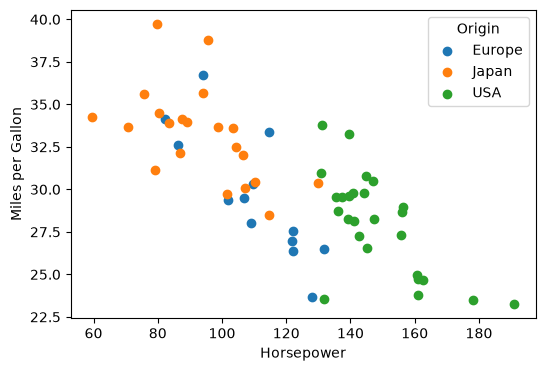

In [32]:

fig, ax = plt.subplots(figsize=(6, 4))
for origin, group in cars.groupby("Origin"):
    ax.scatter(group["Horsepower"], group["Miles_per_Gallon"], label=origin)
ax.set_xlabel("Horsepower")
ax.set_ylabel("Miles per Gallon")
ax.legend(title="Origin")
plt.show()



* We can also compute grouped density estimates directly from a `DataFrame`, using `scipy.stats.gaussian_kde` together with `matplotlib`


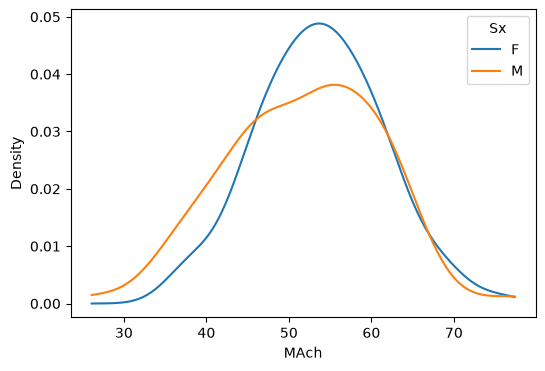

In [33]:

from scipy import stats


np.random.seed(6318)


n = 200
sex = np.random.choice(["M", "F"], size=n)
sector = np.random.choice(["Public", "Private"], size=n)
base = np.where(sex == "M", 50, 52) + np.where(sector == "Private", 4, 0)
mach_score = base + np.random.normal(0, 8, n)


school = pd.DataFrame({"MAch": mach_score, "Sx": sex, "Sector": sector})


fig, ax = plt.subplots(figsize=(6, 4))
grid = np.linspace(school["MAch"].min(), school["MAch"].max(), 200)
for sx, group in school.groupby("Sx"):
    density = stats.gaussian_kde(group["MAch"])
    ax.plot(grid, density(grid), label=sx)
ax.set_xlabel("MAch")
ax.set_ylabel("Density")
ax.legend(title="Sx")
plt.show()


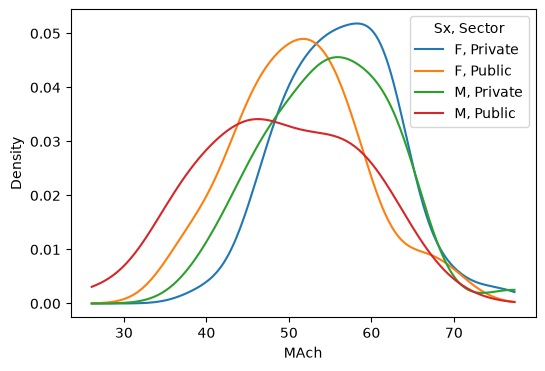

In [34]:

fig, ax = plt.subplots(figsize=(6, 4))
for (sx, sec), group in school.groupby(["Sx", "Sector"]):
    density = stats.gaussian_kde(group["MAch"])
    ax.plot(grid, density(grid), label=f"{sx}, {sec}")
ax.set_xlabel("MAch")
ax.set_ylabel("Density")
ax.legend(title="Sx, Sector")
plt.show()
